In [30]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp

#### Bài 2

In [10]:
DATASET_ROOT = Path('dataset')
IMAGES_DIR = DATASET_ROOT / 'train_images'
MASKS_DIR = DATASET_ROOT / 'train_masks'

class DatasetExplorer:
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / 'train_images'
        self.masks_dir = self.root_dir / 'train_masks'

    def list_files(self):
        images = sorted([p.name for p in self.images_dir.glob('*.jpg')])
        masks = sorted([p.name for p in self.masks_dir.glob('*.png')])
        return images, masks

    def verify_pairs(self):
        images, masks = self.list_files()
        image_keys = {Path(f).stem for f in images}
        mask_keys = {Path(f).stem for f in masks}
        matched = sorted(image_keys & mask_keys)
        missing_images = sorted(mask_keys - image_keys)
        missing_masks = sorted(image_keys - mask_keys)
        return matched, missing_images, missing_masks

    def sample_shapes(self, limit=5):
        results = []
        valid_images = sorted(self.images_dir.glob('*.jpg'))
        for image_name in valid_images[:limit]:
            mask_name = self.masks_dir / f'{image_name.stem}.png'
            if not mask_name.exists():
                continue
            image = cv2.imread(str(image_name))
            mask = cv2.imread(str(mask_name), cv2.IMREAD_GRAYSCALE)
            results.append((
                image_name.name,
                image.shape if image is not None else None,
                mask.shape if mask is not None else None,
                np.unique(mask).tolist() if mask is not None else []
            ))
        return results

    def get_valid_pairs(self):
        matched, _, _ = self.verify_pairs()
        image_lookup = {p.stem: p for p in self.images_dir.glob('*.jpg')}
        mask_lookup = {p.stem: p for p in self.masks_dir.glob('*.png')}
        image_paths = [image_lookup[k] for k in matched]
        mask_paths = [mask_lookup[k] for k in matched]
        return image_paths, mask_paths


explorer = DatasetExplorer(DATASET_ROOT)
matched, missing_images, missing_masks = explorer.verify_pairs()
print('Matched pairs:', len(matched))
print('Missing images:', len(missing_images))
print('Missing masks:', len(missing_masks))
print('Sample shapes and mask values:')
for item in explorer.sample_shapes(5):
    print(item)


Matched pairs: 5088
Missing images: 0
Missing masks: 0
Sample shapes and mask values:
('00087a6bd4dc_01.jpg', (1280, 1918, 3), (1280, 1918), [0, 1])
('00087a6bd4dc_02.jpg', (1280, 1918, 3), (1280, 1918), [0, 1])
('00087a6bd4dc_03.jpg', (1280, 1918, 3), (1280, 1918), [0, 1])
('00087a6bd4dc_04.jpg', (1280, 1918, 3), (1280, 1918), [0, 1])
('00087a6bd4dc_05.jpg', (1280, 1918, 3), (1280, 1918), [0, 1])


#### Bài 3

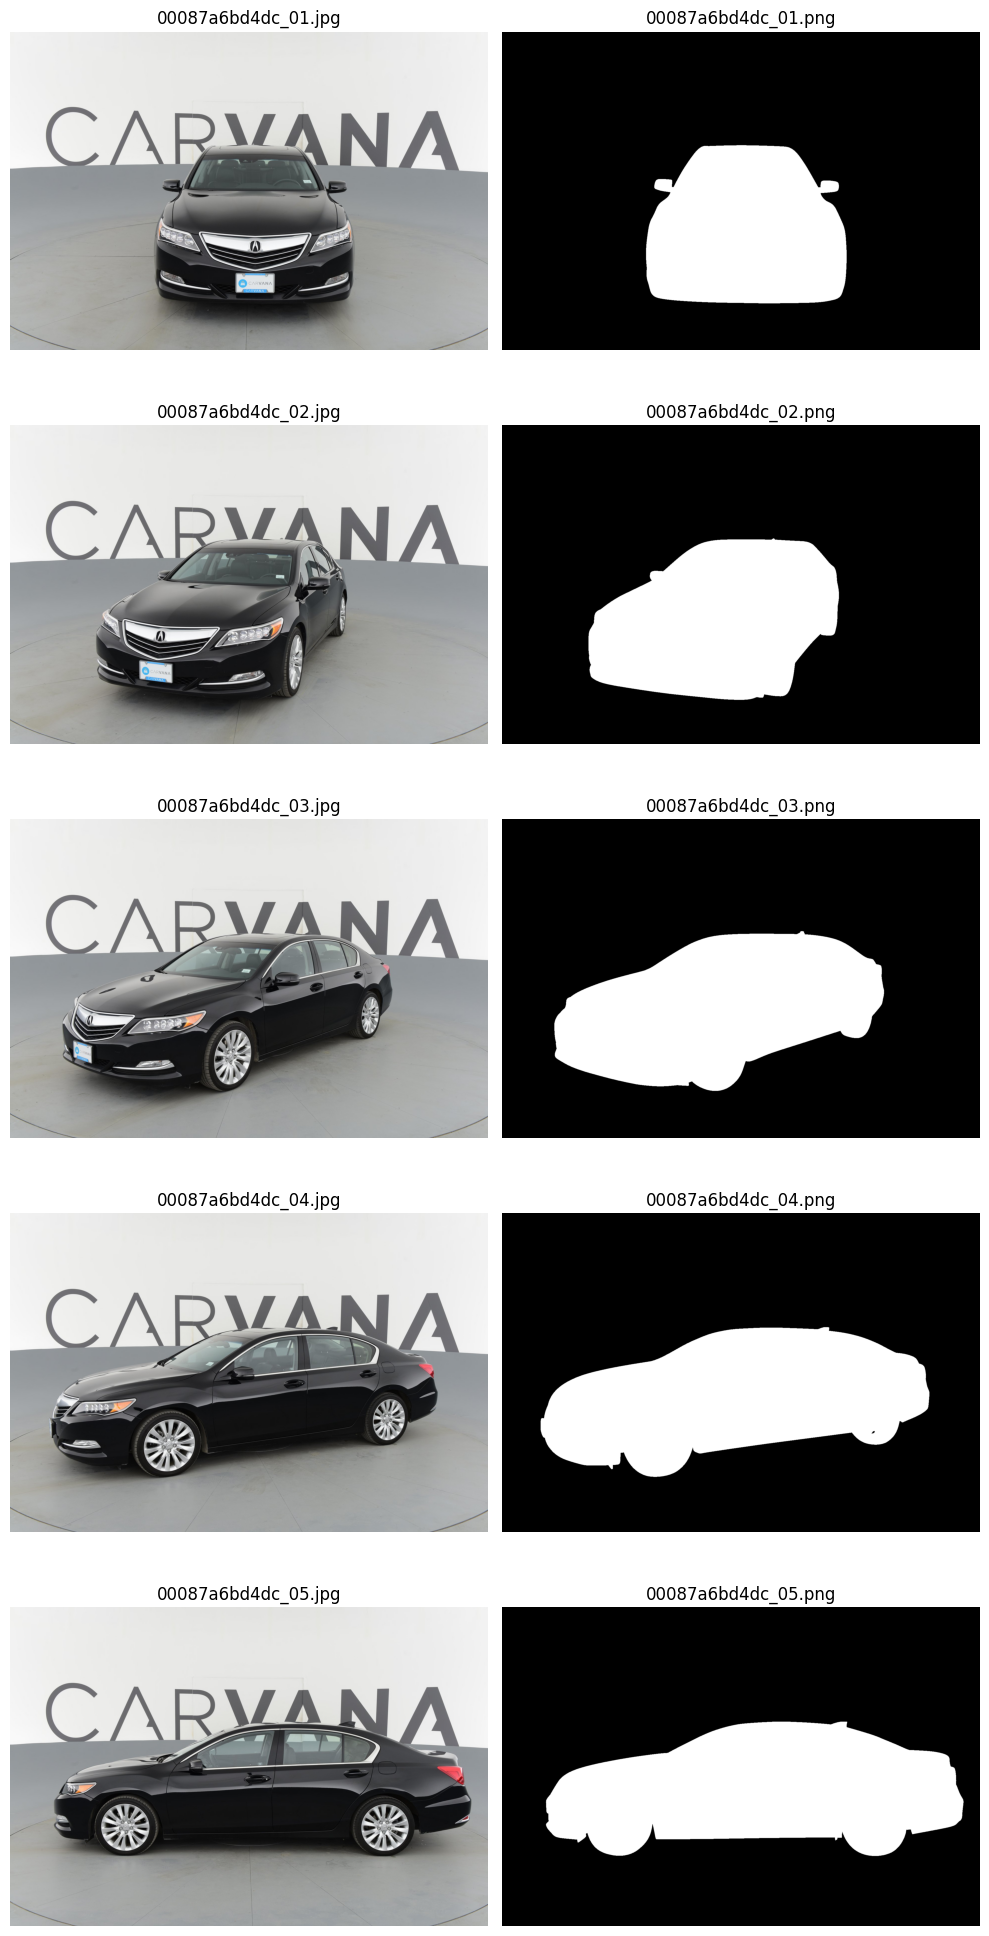

In [11]:
def show_samples(root_dir, num_samples=5):
    explorer = DatasetExplorer(root_dir)
    image_paths, mask_paths = explorer.get_valid_pairs()
    pairs = list(zip(image_paths, mask_paths))[:num_samples]
    fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 4 * len(pairs)))
    axes = np.atleast_2d(axes)

    for row, (image_path, mask_path) in enumerate(pairs):
        image = cv2.imread(str(image_path))
        if image is None:
            raise FileNotFoundError(f'Unable to read image: {image_path}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f'Unable to read mask: {mask_path}')

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(image_path.name)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(mask, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title(mask_path.name)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(DATASET_ROOT, num_samples=5)

#### Bài 4

In [12]:
def split_dataset(root_dir, test_size=0.2, random_state=42):
    explorer = DatasetExplorer(root_dir)
    image_paths, mask_paths = explorer.get_valid_pairs()
    train_images, val_images, train_masks, val_masks = train_test_split(
        image_paths,
        mask_paths,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
    )
    return train_images, val_images, train_masks, val_masks

train_images, val_images, train_masks, val_masks = split_dataset(DATASET_ROOT)
print('Train samples:', len(train_images))
print('Val samples:', len(val_images))


Train samples: 4070
Val samples: 1018


#### Bài 5

In [13]:
class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, image_size=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.image_size = image_size
        self.mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)
        assert len(self.image_paths) == len(self.mask_paths)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = cv2.imread(str(image_path))
        if image is None:
            raise FileNotFoundError(f'Unable to read image: {image_path}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_LINEAR)
        image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        image = (image - self.mean) / self.std

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f'Unable to read mask: {mask_path}')
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        mask = (mask > 0.5).float()

        return image, mask

dataset = SegmentationDataset(train_images, train_masks, image_size=(256, 256))
print('Dataset size:', len(dataset))

Dataset size: 4070


#### Bài 6

In [14]:
image_paths, mask_paths = explorer.get_valid_pairs()

train_images, val_images, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

train_dataset = SegmentationDataset(train_images, train_masks, image_size=(256, 256))
val_dataset = SegmentationDataset(val_images, val_masks, image_size=(256, 256))

pin_memory = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0, pin_memory=pin_memory)

print('Train batches:', len(train_loader))
print('Val batches:', len(val_loader))
sample_images, sample_masks = next(iter(train_loader))
print('Batch image shape:', sample_images.shape)
print('Batch mask shape:', sample_masks.shape)

Train batches: 509
Val batches: 128
Batch image shape: torch.Size([8, 3, 256, 256])
Batch mask shape: torch.Size([8, 1, 256, 256])


#### Bài 7

In [15]:
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.out = nn.Conv2d(16, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        x = self.pool1(e1)
        e2 = self.enc2(x)
        x = self.pool2(e2)
        x = self.bottleneck(x)
        x = self.up2(x)
        x = torch.cat([x, e2], dim=1)
        x = self.dec2(x)
        x = self.up1(x)
        x = torch.cat([x, e1], dim=1)
        x = self.dec1(x)
        x = self.out(x)
        return self.sigmoid(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

num_epochs = 10
bce_train_losses = []
bce_val_losses = []
for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    bce_train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_loader.dataset)
    bce_val_losses.append(val_loss)

    print(f'Epoch {epoch}/{num_epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f}')

Epoch 1/10 - train loss: 0.1383 - val loss: 0.0446
Epoch 2/10 - train loss: 0.0399 - val loss: 0.0731
Epoch 3/10 - train loss: 0.0345 - val loss: 0.0288
Epoch 4/10 - train loss: 0.0228 - val loss: 0.0299
Epoch 5/10 - train loss: 0.0206 - val loss: 0.0177
Epoch 6/10 - train loss: 0.0164 - val loss: 0.0168
Epoch 7/10 - train loss: 0.0168 - val loss: 0.0156
Epoch 8/10 - train loss: 0.0144 - val loss: 0.0163
Epoch 9/10 - train loss: 0.0136 - val loss: 0.0182
Epoch 10/10 - train loss: 0.0156 - val loss: 0.0126


#### Bài 8 - Thử nghiệm Dice Loss

In [16]:
class DiceLoss(nn.Module):
    """
    Dice Loss cho semantic segmentation
    Công thức: DiceLoss = 1 - (2 * intersection) / (union)
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        """
        pred: model output, shape (batch, 1, H, W), range [0, 1]
        target: ground truth, shape (batch, 1, H, W), range [0, 1]
        """
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice

# Khởi tạo model mới cho Dice Loss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model_dice = SimpleUNet().to(device)
criterion_dice = DiceLoss()
optimizer_dice = optim.Adam(model_dice.parameters(), lr=1e-3)

print("\n=== Training với Dice Loss ===")
dice_train_losses = []
dice_val_losses = []

for epoch in range(10):
    model_dice.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        preds = model_dice(images)
        loss = criterion_dice(preds, masks)
        optimizer_dice.zero_grad()
        loss.backward()
        optimizer_dice.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    dice_train_losses.append(train_loss)
    
    model_dice.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            preds = model_dice(images)
            val_loss += criterion_dice(preds, masks).item()
    val_loss /= len(val_loader)
    dice_val_losses.append(val_loss)
    
    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

Using device: cuda

=== Training với Dice Loss ===
Epoch 1: train_loss=0.1618, val_loss=0.0703
Epoch 2: train_loss=0.0454, val_loss=0.0315
Epoch 3: train_loss=0.0328, val_loss=0.0251
Epoch 4: train_loss=0.0294, val_loss=0.0298
Epoch 5: train_loss=0.0284, val_loss=0.0218
Epoch 6: train_loss=0.0196, val_loss=0.0192
Epoch 7: train_loss=0.0171, val_loss=0.0313
Epoch 8: train_loss=0.0167, val_loss=0.0143
Epoch 9: train_loss=0.0148, val_loss=0.0144
Epoch 10: train_loss=0.0135, val_loss=0.0142


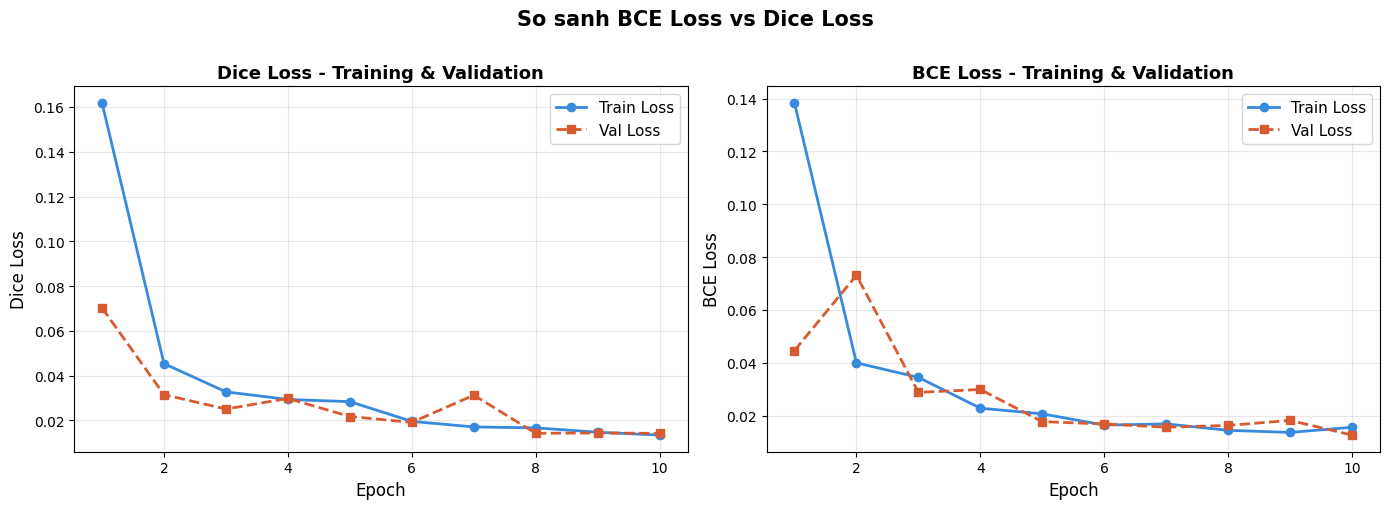

In [17]:
epochs = list(range(1, len(bce_train_losses) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So sanh BCE Loss vs Dice Loss', fontsize=15, fontweight='bold', y=1.01)

axes[0].plot(epochs, dice_train_losses, 'o-', label='Train Loss', linewidth=2, color='#378ADD')
axes[0].plot(epochs, dice_val_losses, 's--', label='Val Loss', linewidth=2, color='#D85A30')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Dice Loss', fontsize=12)
axes[0].set_title('Dice Loss - Training & Validation', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, bce_train_losses, 'o-', label='Train Loss', linewidth=2, color='#378ADD')
axes[1].plot(epochs, bce_val_losses, 's--', label='Val Loss', linewidth=2, color='#D85A30')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('BCE Loss', fontsize=12)
axes[1].set_title('BCE Loss - Training & Validation', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Bài 9 - Tính IoU trên Validation Set

In [18]:
def compute_batch_iou(pred_masks, true_masks, threshold=0.5, eps=1e-6):
    pred_masks = (pred_masks > threshold).float()
    true_masks = (true_masks > 0.5).float()
    intersection = (pred_masks * true_masks).sum(dim=(1, 2, 3))
    union = ((pred_masks + true_masks) > 0).float().sum(dim=(1, 2, 3))
    return (intersection + eps) / (union + eps)


def evaluate_mean_iou(model, data_loader, device):
    model.eval()
    iou_scores = []
    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.to(device)
            preds = model(images)
            batch_ious = compute_batch_iou(preds, masks)
            iou_scores.extend(batch_ious.cpu().tolist())
    return float(np.mean(iou_scores)), iou_scores


mean_iou_bce, iou_scores_bce = evaluate_mean_iou(model, val_loader, device)
mean_iou_dice, iou_scores_dice = evaluate_mean_iou(model_dice, val_loader, device)

print(f'Mean IoU (BCE model): {mean_iou_bce:.4f}')
print(f'Mean IoU (Dice model): {mean_iou_dice:.4f}')
print(f'So mau validation da danh gia: {len(iou_scores_bce)}')

Mean IoU (BCE model): 0.9780
Mean IoU (Dice model): 0.9729
So mau validation da danh gia: 1018


#### bài 10 

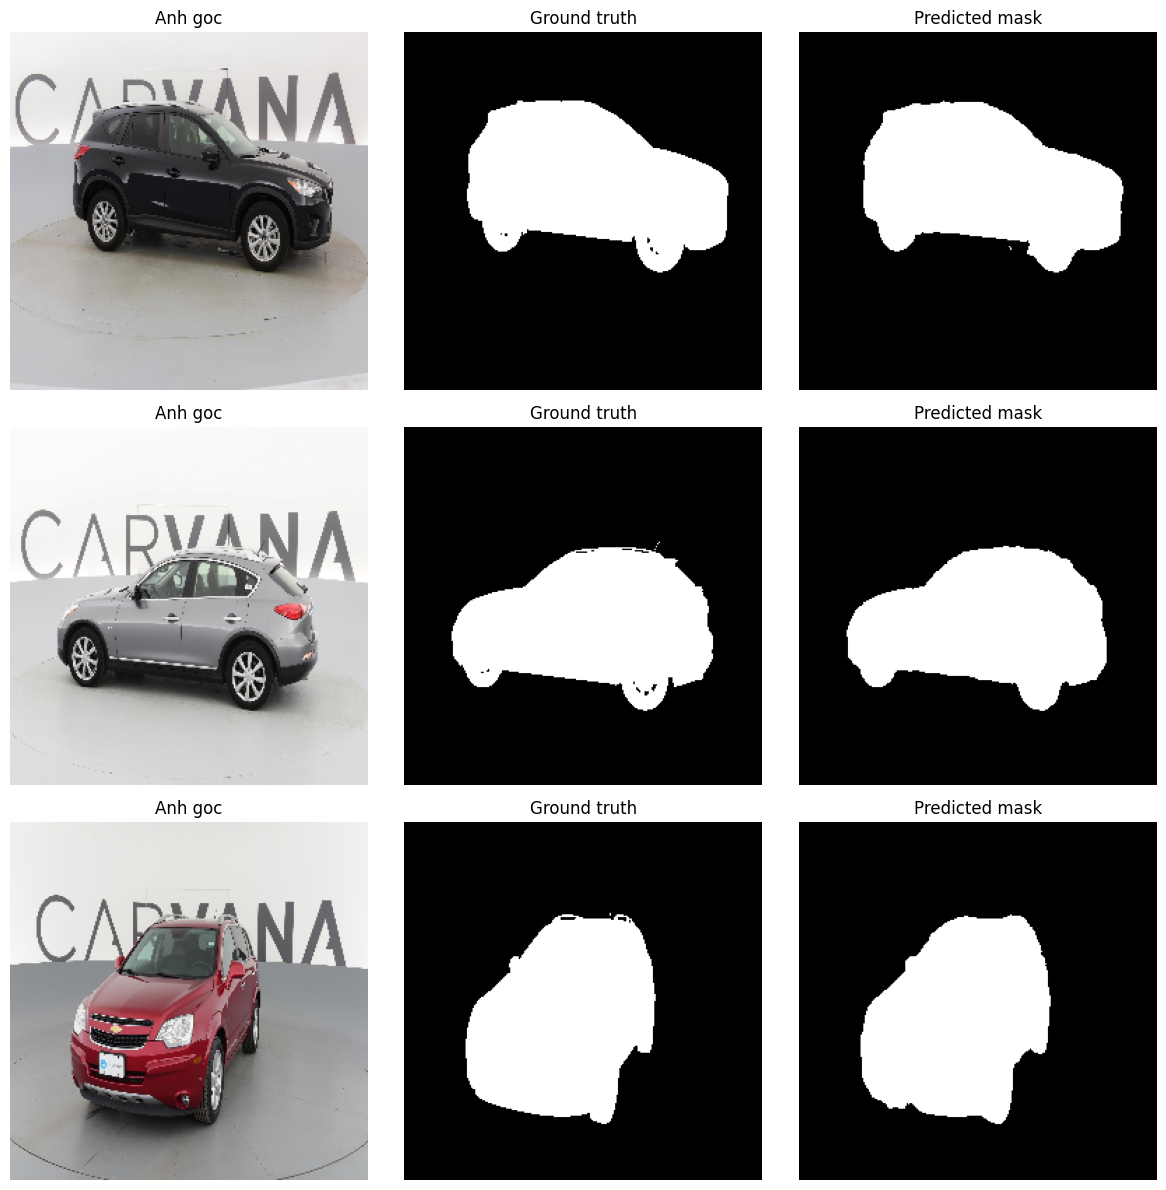

In [ ]:
def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    if num_samples == 1:
        axes = np.array([axes])

    with torch.no_grad():
        for i in range(num_samples):
            image, true_mask = dataset[i]
            pred = model(image.unsqueeze(0).to(device)).squeeze(0).cpu()
            pred_mask = (pred > 0.5).float()

            image_np = image.permute(1, 2, 0).cpu() * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
            image_np = image_np.clamp(0, 1).numpy()

            axes[i, 0].imshow(image_np)
            axes[i, 0].set_title("Anh goc")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(true_mask.squeeze(0), cmap="gray", vmin=0, vmax=1)
            axes[i, 1].set_title("Ground truth")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(pred_mask.squeeze(0), cmap="gray", vmin=0, vmax=1)
            axes[i, 2].set_title("Predicted mask")
            axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_dataset, device, num_samples=3)

#### Exercise 11 - Compare Learning Rates

In [ ]:
learning_rates = [1e-2, 1e-3, 1e-4]
lr_results = {}

for lr in learning_rates:
    model_lr = SimpleUNet().to(device)
    optimizer_lr = optim.Adam(model_lr.parameters(), lr=lr)
    criterion_lr = nn.BCELoss()

    for epoch in range(1, 4):
        model_lr.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer_lr.zero_grad()
            outputs = model_lr(images)
            loss = criterion_lr(outputs, masks)
            loss.backward()
            optimizer_lr.step()
            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        model_lr.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model_lr(images)
                loss = criterion_lr(outputs, masks)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(val_loader.dataset)
        print(f'LR = {lr:.0e} | Epoch {epoch}/3 | Train Loss = {train_loss:.4f} | Val Loss = {val_loss:.4f}')

    mean_iou, _ = evaluate_mean_iou(model_lr, val_loader, device)
    lr_results[lr] = mean_iou

print('Learning Rate Comparison:')
for lr, mean_iou in lr_results.items():
    print(f'LR = {lr:.0e} | Mean IoU = {mean_iou:.4f}')


#### Exercise 12 - Compare Batch Sizes

In [ ]:
batch_sizes = [4, 8, 16]
batch_results = {}

for batch_size in batch_sizes:
    train_loader_bs = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
    val_loader_bs = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)

    model_bs = SimpleUNet().to(device)
    optimizer_bs = optim.Adam(model_bs.parameters(), lr=1e-3)
    criterion_bs = nn.BCELoss()

    for epoch in range(1, 4):
        model_bs.train()
        train_loss = 0.0
        for images, masks in train_loader_bs:
            images, masks = images.to(device), masks.to(device)
            optimizer_bs.zero_grad()
            outputs = model_bs(images)
            loss = criterion_bs(outputs, masks)
            loss.backward()
            optimizer_bs.step()
            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader_bs.dataset)

        model_bs.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader_bs:
                images, masks = images.to(device), masks.to(device)
                outputs = model_bs(images)
                loss = criterion_bs(outputs, masks)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(val_loader_bs.dataset)
        print(f'Batch Size = {batch_size} | Epoch {epoch}/3 | Train Loss = {train_loss:.4f} | Val Loss = {val_loss:.4f}')

    mean_iou, _ = evaluate_mean_iou(model_bs, val_loader_bs, device)
    batch_results[batch_size] = mean_iou

print('Batch Size Comparison:')
for batch_size, mean_iou in batch_results.items():
    print(f'Batch Size = {batch_size} | Mean IoU = {mean_iou:.4f}')


#### Exercise 13 - Show Low-IoU Samples

In [ ]:
sample_ious = collect_sample_ious(model, val_dataset, device)[:5]
print('Lowest IoU samples:')
for idx, iou in sample_ious:
    print(f'Index = {idx} | IoU = {iou:.4f}')


#### Exercise 14 - Suggest Ways to Improve the Model

In [ ]:
improvement_suggestions = [
    'Increase the dataset size or add more diverse training samples.',
    'Apply data augmentation such as flip, rotation, and brightness changes.',
    'Train for more epochs and use early stopping to reduce overfitting.',
    'Combine BCE Loss with Dice Loss for better segmentation performance.',
    'Tune learning rate and batch size to find a better training setup.',
    'Try stronger architectures such as U-Net++, DeepLabV3, or pretrained encoders.',
]

print('Suggestions to improve the model:')
for i, suggestion in enumerate(improvement_suggestions, start=1):
    print(f'{i}. {suggestion}')


#### Exercise 15 - Try Another Segmentation Architecture

In [ ]:
if smp is None:
    print('segmentation_models_pytorch is not installed, skipping Exercise 15.')
else:
    model_smp = smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation='sigmoid',
    ).to(device)

    optimizer_smp = optim.Adam(model_smp.parameters(), lr=1e-3)
    criterion_smp = nn.BCELoss()

    smp_train_losses = []
    smp_val_losses = []

    for epoch in range(1, 4):
        model_smp.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer_smp.zero_grad()
            outputs = model_smp(images)
            loss = criterion_smp(outputs, masks)
            loss.backward()
            optimizer_smp.step()
            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        smp_train_losses.append(train_loss)

        model_smp.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model_smp(images)
                loss = criterion_smp(outputs, masks)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(val_loader.dataset)
        smp_val_losses.append(val_loss)
        print(f'Epoch {epoch}/3 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    mean_iou_smp, _ = evaluate_mean_iou(model_smp, val_loader, device)
    print(f'Mean IoU (smp.Unet - resnet34): {mean_iou_smp:.4f}')
    visualize_predictions(model_smp, val_dataset, device, num_samples=3)
